## Model C: Regularized

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\lamaa\.cache\kagglehub\datasets\rashikrahmanpritom\plant-disease-recognition-dataset\versions\1


In [4]:
import os

# Walk through the dataset directory and print its structure
for root, dirs, files in os.walk(path):
    # Calculate the folder depth for indentation
    level = root.replace(path, "").count(os.sep)
    indent = " " * 2 * level

    print(f"{indent}{os.path.basename(root)}/")

    # Show only the first 3 files in each folder (avoid long output)
    sub_indent = " " * 2 * (level + 1)
    for file in files[:3]:
        print(f"{sub_indent}{file}")

    if len(files) > 3:
        print(f"{sub_indent}... and {len(files) - 3} more files")

1/
  Test/
    Test/
      Healthy/
        8ddaa5a5caa5caa8.jpg
        8ddaac1bd6c8cd0a.jpg
        8ddd5ec1c0de38c4.jpg
        ... and 47 more files
      Powdery/
        80bc7d353e163e85.jpg
        80f8cdc9854f756a.jpg
        81a3b719b6c2b4da.jpg
        ... and 47 more files
      Rust/
        82add70df6ab2854.jpg
        82f49a4a7b9585f1.jpg
        830f26cc6d3cd13e.jpg
        ... and 47 more files
  Train/
    Train/
      Healthy/
        800edef467d27c15.jpg
        801d6dcd96e48ebc.jpg
        802b59956a7aa5e7.jpg
        ... and 455 more files
      Powdery/
        802f7439ec1ef0cd.jpg
        806d7d0df8cae3c2.jpg
        81352f0c4c5efa9b.jpg
        ... and 427 more files
      Rust/
        807947b90eb77856.jpg
        80933fcc6a673636.jpg
        80f09587dfc7988e.jpg
        ... and 431 more files
  Validation/
    Validation/
      Healthy/
        9bd4cc8c52e9d52a.jpg
        9bdcc23296db1516.jpg
        9be41b823d13e3c6.jpg
        ... and 17 more files
      Po

In [5]:
import os

# Define the exact paths based on the nested folder structure we discovered
train_dir = os.path.join(path, "Train", "Train")
test_dir = os.path.join(path, "Test", "Test")
valid_dir = os.path.join(path, "Validation", "Validation")

class_names = ["Healthy", "Powdery", "Rust"]

# Function to count images in each class folder
def count_images(base_dir, class_names):
    counts = {}
    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        num_files = len(os.listdir(class_path))
        counts[class_name] = num_files
    return counts

print("Train counts:", count_images(train_dir, class_names))
print("Test counts:", count_images(test_dir, class_names))
print("Validation counts:", count_images(valid_dir, class_names))

Train counts: {'Healthy': 458, 'Powdery': 430, 'Rust': 434}
Test counts: {'Healthy': 50, 'Powdery': 50, 'Rust': 50}
Validation counts: {'Healthy': 20, 'Powdery': 20, 'Rust': 20}


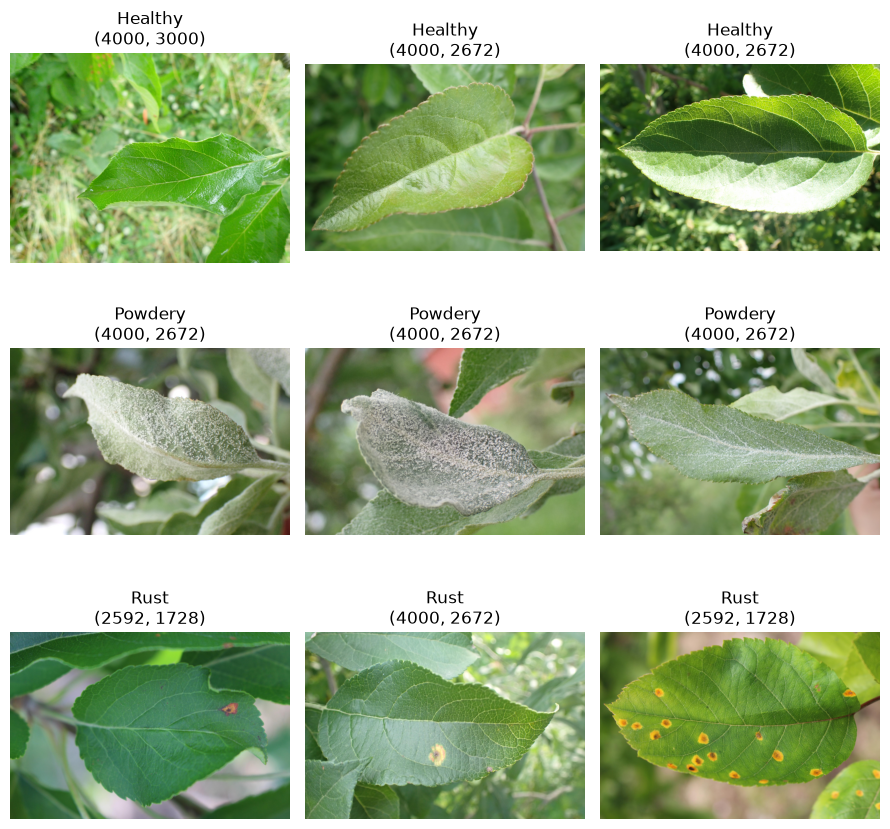

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

# Create a grid: 3 rows (one per class), 3 columns (sample images)
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for row, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    # Get the first 3 image filenames in this class folder
    sample_files = os.listdir(class_path)[:3]

    for col, file_name in enumerate(sample_files):
        img_path = os.path.join(class_path, file_name)
        img = Image.open(img_path)

        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(f"{class_name}\n{img.size}")
        ax.axis("off")

plt.tight_layout()
plt.show()

### Input Resizing

In [7]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 42

# Load the training dataset directly from folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

# Load the validation dataset
valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

# Load the test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.


In [8]:
# NOTE: Speeding up the data pipeline before training
# - cache()    -> keeps images in memory after first read (faster next epoch)
# - shuffle()  -> randomizes order (train set only)
# - prefetch() -> prepares next batch while current one is training

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)   # no shuffle: keep order fixed for evaluation
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)     # no shuffle: keep order fixed for evaluation

In [9]:
from tensorflow.keras import layers, Model

def build_model_c(num_classes: int) -> Model:
    inputs = keras.Input(shape=(160, 160, 3))

    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)   # Changed from default 0.99
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)   # Changed from default 0.99
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)   # Changed from default 0.99
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="Model_C_Regularized")


model_c = build_model_c(num_classes=len(class_names))
model_c.summary()

Model: "Model_C_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 160, 160, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,307 (368.39 KB)

 Trainable params: 93,859 (366.64 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:



model_c.compile(
    optimizer= "adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="model_c_best.keras",
    monitor="val_loss",
    save_best_only=True
)

history_c = model_c.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 356ms/step - accuracy: 0.8714 - loss: 0.3446 - val_accuracy: 0.7833 - val_loss: 0.6107
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 348ms/step - accuracy: 0.8820 - loss: 0.3286 - val_accuracy: 0.8333 - val_loss: 0.4530
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 348ms/step - accuracy: 0.8979 - loss: 0.2961 - val_accuracy: 0.4333 - val_loss: 2.3281
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 344ms/step - accuracy: 0.8858 - loss: 0.2898 - val_accuracy: 0.7000 - val_loss: 0.7080
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step - accuracy: 0.8971 - loss: 0.2767 - val_accuracy: 0.5500 - val_loss: 1.2185
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step - accuracy: 0.9160 - loss: 0.2483 - val_accuracy: 0.5333 - val_loss: 2.4955
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 350ms/step - accuracy: 0.9047 - loss: 0.2747 - val_accuracy: 0.8500 - val_loss: 0.3696
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 349ms/step - accuracy: 0.9213 - loss: 0.2408 - val_accu

In [20]:
import numpy as np

# Find the epoch with the lowest validation loss
val_loss_values = history_c.history["val_loss"]
best_epoch = np.argmin(val_loss_values)

print(f"Best epoch: {best_epoch + 1}")
print(f"Best val_loss: {val_loss_values[best_epoch]:.4f}")
print(f"Best val_accuracy: {history_c.history['val_accuracy'][best_epoch]:.4f}")

Best epoch: 7
Best val_loss: 0.3696
Best val_accuracy: 0.8500


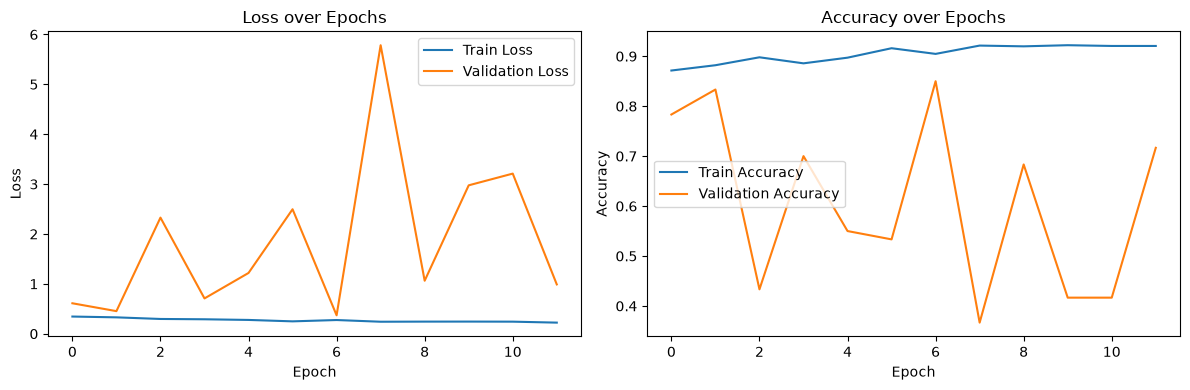

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Loss curves
axes[0].plot(history_c.history["loss"], label="Train Loss")
axes[0].plot(history_c.history["val_loss"], label="Validation Loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot 2: Accuracy curves
axes[1].plot(history_c.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_c.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()